Congrats! You just graduated UVA's BSDS program and got a job working at a movie studio in Hollywood. 

Your boss is the head of the studio and wants to know if they can gain a competitive advantage by predicting new movies that might get high imdb scores (movie rating). 

You would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so, similar to  great data scientists of the past you remembered the excellent education provided to you at UVA in a undergrad data science course and have outline 20ish steps that will need to be undertaken to complete this task. As always, you will need to make sure to #comment your work heavily. 

 Footnotes: 
-	You can add or combine steps if needed
-	Also, remember to try several methods during evaluation and always be mindful of how the model will be used in practice.
- Make sure all your variables are the correct type (factor, character,numeric, etc.)

In [85]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import graphviz
import os
from sklearn.model_selection import train_test_split,GridSearchCV,RepeatedStratifiedKFold
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, classification_report
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import plot_tree, DecisionTreeClassifier, export_graphviz

#1. Load the data

In [2]:
#Sometimes need to set the working directory back out of a folder that we create a file in

#import os
#os.listdir()
#print(os.getcwd())
#os.chdir('c:\\Users\\Brian Wright\\Documents\\3001Python\\DS-3001')

movie_metadata=pd.read_csv("../data/movie_metadata.csv")



#2 Ensure all the variables are classified correctly including the target variable and collapse factor variables as needed.

In [3]:
print(movie_metadata.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [4]:
#We should change the object variables into categorical variables and do one-hot encoding or change them as numeric variables.
#First I would like to see which columns are objects
object_columns=movie_metadata.select_dtypes(include=['object']).columns
print(object_columns)

Index(['color', 'director_name', 'actor_2_name', 'genres', 'actor_1_name',
       'movie_title', 'actor_3_name', 'plot_keywords', 'movie_imdb_link',
       'language', 'country', 'content_rating'],
      dtype='object')


In [5]:
#I will remove plot_keywords, movie_imdb_link, language, country, genres, and movie title as they are quite irrelevant
movie_metadata = movie_metadata.drop(columns=['plot_keywords', "color",'movie_imdb_link','language','country', 'genres', 'movie_title'])
print(movie_metadata.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   director_name              4939 non-null   object 
 1   num_critic_for_reviews     4993 non-null   float64
 2   duration                   5028 non-null   float64
 3   director_facebook_likes    4939 non-null   float64
 4   actor_3_facebook_likes     5020 non-null   float64
 5   actor_2_name               5030 non-null   object 
 6   actor_1_facebook_likes     5036 non-null   float64
 7   gross                      4159 non-null   float64
 8   actor_1_name               5036 non-null   object 
 9   num_voted_users            5043 non-null   int64  
 10  cast_total_facebook_likes  5043 non-null   int64  
 11  actor_3_name               5020 non-null   object 
 12  facenumber_in_poster       5030 non-null   float64
 13  num_user_for_reviews       5022 non-null   float

In [6]:
#For movie and actor names, if they appear three times or more, I will label them as famous. 
name_columns = ['actor_1_name', 'actor_2_name', 'actor_3_name', 'director_name']
for col in name_columns:
    counts = movie_metadata[col].value_counts()
    movie_metadata[col] = np.where(movie_metadata[col].isin(counts[counts >= 3].index),
    'famous',
    'not_famous'
)
    movie_metadata[col] = movie_metadata[col].map({'famous': 1, 'not_famous': 0}).astype(int)

    

In [7]:
print(movie_metadata.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   director_name              5043 non-null   int64  
 1   num_critic_for_reviews     4993 non-null   float64
 2   duration                   5028 non-null   float64
 3   director_facebook_likes    4939 non-null   float64
 4   actor_3_facebook_likes     5020 non-null   float64
 5   actor_2_name               5043 non-null   int64  
 6   actor_1_facebook_likes     5036 non-null   float64
 7   gross                      4159 non-null   float64
 8   actor_1_name               5043 non-null   int64  
 9   num_voted_users            5043 non-null   int64  
 10  cast_total_facebook_likes  5043 non-null   int64  
 11  actor_3_name               5043 non-null   int64  
 12  facenumber_in_poster       5030 non-null   float64
 13  num_user_for_reviews       5022 non-null   float

In [8]:
#For the content_rating column, I will replace the values by two: R-rated and non-R-rated.
def categorized_content_rating(rating):
    if rating == 'R':
        return 1
    else:
        return 0
movie_metadata['content_rating'] = movie_metadata['content_rating'].map(categorized_content_rating)
print(movie_metadata.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   director_name              5043 non-null   int64  
 1   num_critic_for_reviews     4993 non-null   float64
 2   duration                   5028 non-null   float64
 3   director_facebook_likes    4939 non-null   float64
 4   actor_3_facebook_likes     5020 non-null   float64
 5   actor_2_name               5043 non-null   int64  
 6   actor_1_facebook_likes     5036 non-null   float64
 7   gross                      4159 non-null   float64
 8   actor_1_name               5043 non-null   int64  
 9   num_voted_users            5043 non-null   int64  
 10  cast_total_facebook_likes  5043 non-null   int64  
 11  actor_3_name               5043 non-null   int64  
 12  facenumber_in_poster       5030 non-null   float64
 13  num_user_for_reviews       5022 non-null   float

In [9]:
#The target variable will be imdb_score
print(movie_metadata.imdb_score.value_counts())

imdb_score
6.7    223
6.6    201
7.2    195
6.5    186
6.4    185
      ... 
1.7      1
9.3      1
9.5      1
1.6      1
9.2      1
Name: count, Length: 78, dtype: int64


In [10]:
#Instead of rounding up to a whole number, I will create four bins and classify them
def categorized_imdb(scores):
    if scores < 5.0:
        return "poor"
    elif scores < 6.5:
        return "average"
    elif scores < 8.0:
        return "good"
    else: 
        return "excellent"

movie_metadata["imdbscore_category"] = movie_metadata["imdb_score"].apply(categorized_imdb)

#3 Check for missing variables and correct as needed.

In [11]:
print(movie_metadata.isna().sum())

director_name                  0
num_critic_for_reviews        50
duration                      15
director_facebook_likes      104
actor_3_facebook_likes        23
actor_2_name                   0
actor_1_facebook_likes         7
gross                        884
actor_1_name                   0
num_voted_users                0
cast_total_facebook_likes      0
actor_3_name                   0
facenumber_in_poster          13
num_user_for_reviews          21
content_rating                 0
budget                       492
title_year                   108
actor_2_facebook_likes        13
imdb_score                     0
aspect_ratio                 329
movie_facebook_likes           0
imdbscore_category             0
dtype: int64


In [12]:
movie_metadata = movie_metadata.dropna()

In [13]:
print(movie_metadata.info()) #No na values

<class 'pandas.core.frame.DataFrame'>
Index: 3801 entries, 0 to 5042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   director_name              3801 non-null   int64  
 1   num_critic_for_reviews     3801 non-null   float64
 2   duration                   3801 non-null   float64
 3   director_facebook_likes    3801 non-null   float64
 4   actor_3_facebook_likes     3801 non-null   float64
 5   actor_2_name               3801 non-null   int64  
 6   actor_1_facebook_likes     3801 non-null   float64
 7   gross                      3801 non-null   float64
 8   actor_1_name               3801 non-null   int64  
 9   num_voted_users            3801 non-null   int64  
 10  cast_total_facebook_likes  3801 non-null   int64  
 11  actor_3_name               3801 non-null   int64  
 12  facenumber_in_poster       3801 non-null   float64
 13  num_user_for_reviews       3801 non-null   float64
 1

#4 Guess what, you don't need to scale the data, because DTs don't require this to be done, they make local greedy decisions...keeps getting easier, go to the next step.

#5 Determine the baserate or prevalence for the classifier, what does this number mean?

In [14]:
#print(movie_metadata.imdbscore_category.value_counts())
prevalence_poor = 296/len(movie_metadata)
prevalence_average = 1404/len(movie_metadata)
prevalence_good = 1844/len(movie_metadata)
prevalence_excellent = 211/len(movie_metadata)

prevalence = prevalence_poor, prevalence_average, prevalence_good, prevalence_excellent 
print(prevalence)


(0.07787424362009997, 0.36937647987371747, 0.48513549066035255, 0.055511707445409106)


#6 Split your data into test, tune, and train. (80/10/10)

In [15]:
#Preprocessing 
movie_metadata[["imdbscore_category"]] = OrdinalEncoder().fit_transform(movie_metadata[["imdbscore_category"]])
#print(movie_metadata[["imdbscore_category"]].value_counts()) #The integers are not in order
labels = {3.0: 0.0, 0.0: 1.0, 2.0:2.0, 1.0: 3.0}
movie_metadata["imdbscore_category"] = movie_metadata["imdbscore_category"].map(labels)
print(movie_metadata[["imdbscore_category"]].value_counts())
#The integers are now in order of poor = 0.0, average = 1.0, good = 2.0, excellent = 3.0

imdbscore_category
2.0                   1869
1.0                   1416
0.0                    302
3.0                    214
Name: count, dtype: int64


In [16]:
X = movie_metadata.drop(columns = ["imdbscore_category", "imdb_score"])
y = movie_metadata["imdbscore_category"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=30)
X_tune, X_test, y_tune, y_test = train_test_split(X_test, y_test, test_size=0.5, stratify=y_test, random_state=30)

#7 Create the kfold object for cross validation.

In [17]:
kf = RepeatedStratifiedKFold(n_splits=5,n_repeats =5, random_state=42)

#8 Create the scoring metric you will use to evaluate your model and the max depth hyperparameter 

In [49]:
scoring = {
    "roc_auc": "roc_auc_ovr",
    "recall": "recall_macro",
    "balanced_accuracy": "balanced_accuracy"
}
param = {"max_depth": [1,2,3,4,5,6,7,8,9,10,11]}

#9 Build the classifier object 

In [50]:
cl= DecisionTreeClassifier(random_state=30)

#10 Use the kfold object and the scoring metric to find the best hyperparameter value for max depth via the grid search method.

In [51]:
#grid_search = GridSearchCV(cl, param, scoring = scoring, cv=kf)
search = GridSearchCV(cl, param, scoring = scoring, n_jobs = -1, cv=kf, refit = "roc_auc")

#11 Fit the model to the training data.

In [52]:
model = search.fit(X_train, y_train)

#12 What is the best depth value?

In [53]:
print("Best Depth Value:", model.best_params_['max_depth'])

Best Depth Value: 5


#13 Print out the model

In [54]:
best = model.best_estimator_
print("Best model:", model.best_estimator_)
print(model.best_score_)

Best model: DecisionTreeClassifier(max_depth=5, random_state=30)
0.7857693022992568


#14 View the results, comment on how the model performed using several evaluation metrics.

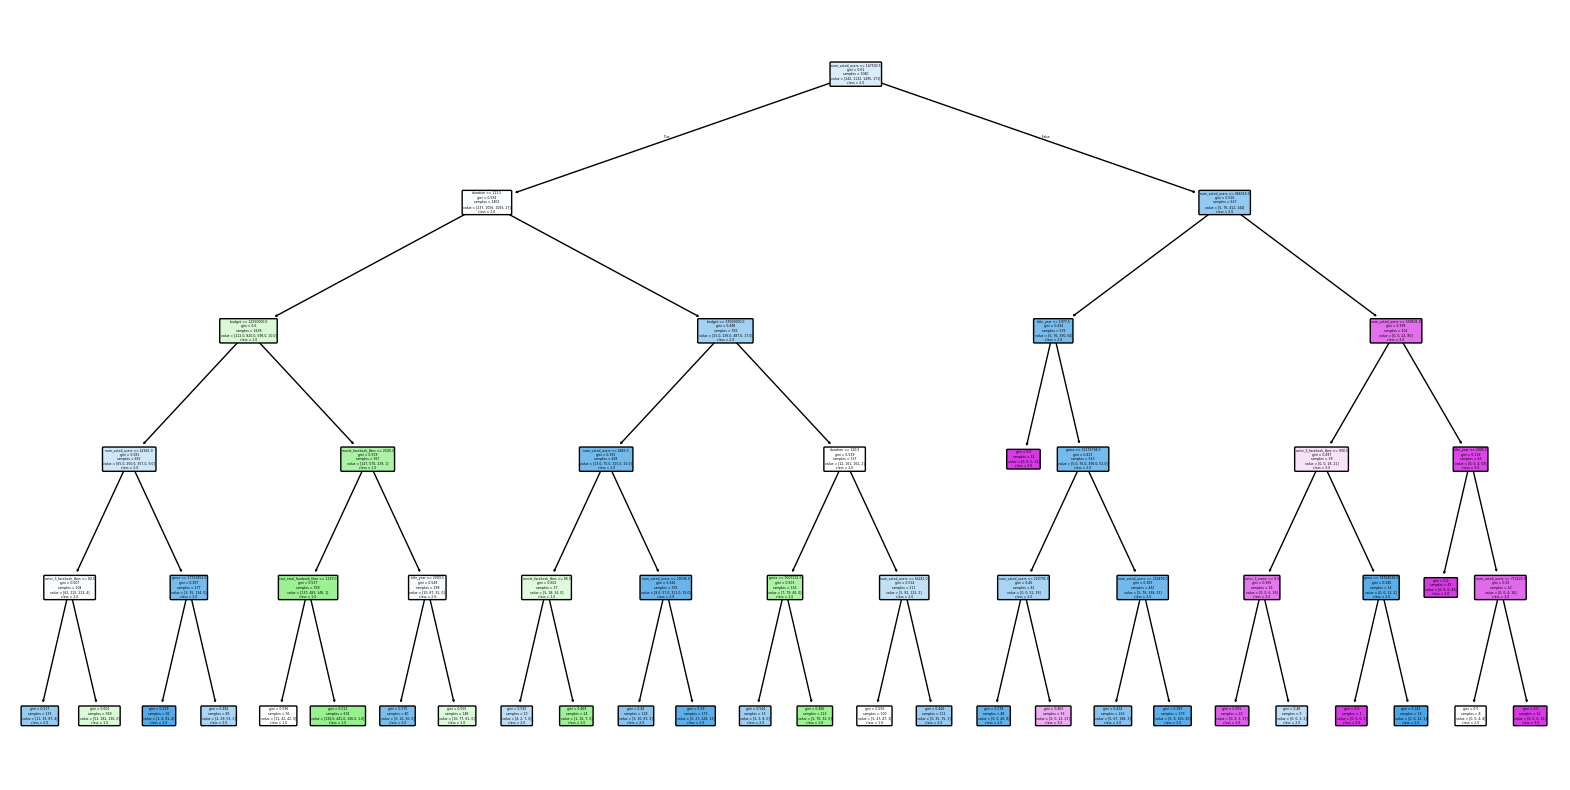

In [55]:
#Creating the decision tree visual for the best estimator 
plt.figure(figsize=(20,10))
plot_tree(best, feature_names=X_train.columns, class_names=['0.0', '1.0', '2.0', '3.0'], filled=True, rounded=True)
plt.show()


In [57]:
print(model.cv_results_)

{'mean_fit_time': array([0.01215713, 0.01838629, 0.02013156, 0.02838336, 0.03764333,
       0.04115604, 0.05725197, 0.04931075, 0.07011846, 0.06719567,
       0.06245705]), 'std_fit_time': array([0.00353047, 0.00498053, 0.00492158, 0.00777144, 0.00973907,
       0.01175495, 0.01747928, 0.00845356, 0.01875042, 0.01969228,
       0.0133581 ]), 'mean_score_time': array([0.01843427, 0.02234107, 0.01659845, 0.02238156, 0.02447023,
       0.02311441, 0.02513112, 0.02098996, 0.02396329, 0.0204085 ,
       0.01725249]), 'std_score_time': array([0.0054445 , 0.00599973, 0.00340063, 0.00830093, 0.00640089,
       0.00878816, 0.00739746, 0.01376706, 0.00895575, 0.00647058,
       0.00586264]), 'param_max_depth': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
             mask=[False, False, False, False, False, False, False, False,
                   False, False, False],
       fill_value=999999), 'params': [{'max_depth': 1}, {'max_depth': 2}, {'max_depth': 3}, {'max_depth': 4}, {'max_dep

In [59]:
auc = model.cv_results_['mean_test_roc_auc']
recall= model.cv_results_['mean_test_recall']
bal_acc= model.cv_results_['mean_test_balanced_accuracy']

SDauc = model.cv_results_['std_test_roc_auc']
SDrecall= model.cv_results_['std_test_recall']
SDbal_acc= model.cv_results_['std_test_balanced_accuracy']

depth= np.unique(model.cv_results_['param_max_depth']).data

#Build DataFrame:
final_model = pd.DataFrame(list(zip(depth, auc, recall, bal_acc,SDauc,SDrecall,SDbal_acc)),
               columns =['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])

#Let's take a look
final_model.style.hide(axis='index')

depth,auc,recall,bal_acc,aucSD,recallSD,bal_accSD
1,0.649643,0.257039,0.257039,0.013486,0.016170,0.016170
2,0.724766,0.427800,0.427800,0.012935,0.023832,0.023832
3,0.762315,0.442405,0.442405,0.011409,0.025991,0.025991
4,0.781048,0.439967,0.439967,0.011744,0.019941,0.019941
5,0.785769,0.464064,0.464064,0.013434,0.022270,0.022270
6,0.785022,0.472485,0.472485,0.016400,0.021761,0.021761
7,0.779815,0.493423,0.493423,0.017065,0.023541,0.023541
8,0.765973,0.499846,0.499846,0.016422,0.020242,0.020242
9,0.750591,0.503895,0.503895,0.019278,0.025927,0.025927
10,0.734750,0.508511,0.508511,0.021048,0.024360,0.024360


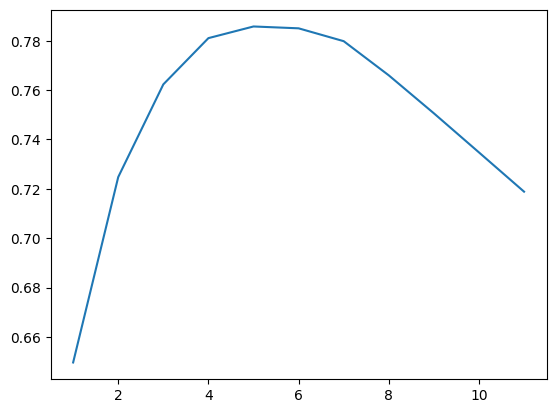

In [60]:
print(plt.plot(final_model.depth,final_model.auc))


The metric "area under the curve" (AUC) shows how well the model separates the classes. Recall means "Of all the true examples of a class, how many did the model correctly identify?", and the balanced accuracy refers to the average of recall in every class.

As seen in the plot above, the AUC is highest when the max depth is 5. The recall value does constantly increase since deeper trees give more flexibility. However, AUC is best when the model has enough power to learn general patterns. At max depth = 5, AUC equals 0.78, which is a pretty good score, especially for multiclass bins like my model.

#15 Which variables appear to be contributing the most (variable importance) 

In [63]:
var_imp = pd.DataFrame(best.feature_importances_, index = X.columns, columns = ["importance"]).sort_values("importance",
                                                                                                           ascending = False)
print(var_imp)

                           importance
num_voted_users              0.466167
budget                       0.174389
duration                     0.151137
title_year                   0.048489
movie_facebook_likes         0.046924
gross                        0.043672
actor_3_facebook_likes       0.043240
cast_total_facebook_likes    0.022626
actor_3_name                 0.003355
director_facebook_likes      0.000000
director_name                0.000000
num_critic_for_reviews       0.000000
actor_1_name                 0.000000
actor_1_facebook_likes       0.000000
actor_2_name                 0.000000
facenumber_in_poster         0.000000
content_rating               0.000000
num_user_for_reviews         0.000000
actor_2_facebook_likes       0.000000
aspect_ratio                 0.000000


Out of all features, the most important ones are number of voted users, budget, and duration. Number of Voted Users seems to have the highest importance than any other features.

#16 Use the predict method on the tune data and print out the results.

In [64]:
tune_model = search.fit(X_tune, y_tune)
print(model.best_score_)

0.6861093200153412


#17 How does the model perform on the tune data?

The model performs a little worst on the tune data compared to the trained data. 

#18 Print out the confusion matrix for the tune data, what does it tell you about the model?

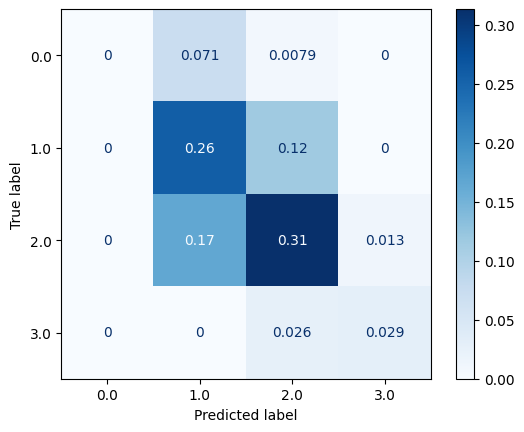

In [65]:
print(ConfusionMatrixDisplay.from_estimator(best, X_tune, y_tune, display_labels = ['0.0', '1.0', '2.0', '3.0'], cmap = "Blues", normalize = "all"))

Based on the Confusion Matrix above, the model performs well on predicting "good" movies as the cluster [2.0, 2.0] since 31% of total predictions were class 2.0 correctly predicted. Likewise, the model also performs well on predicting "average" movies since 26% of total predictions were class 1.0 correctly predicted. However, class "bad" and "excellent" were hard to predict on my model.

#19 What are the top 3 movies based on the test set? Which variables are most important in predicting the top 3 movies?

In [72]:
movie_title=pd.read_csv("../data/movie_metadata.csv")
X_test_copy = X_test.copy()
X_test_copy["movie_title"] = movie_title.loc[X_test.index, "movie_title"].values
probabilities = best.predict_proba(X_test)
class_3_probabilities = probabilities[:, 3] #The top 3 movie will be in the "excellent" class
X_test_copy["predicted_prob_3.0"] = class_3_probabilities
top_3_movies = X_test_copy.sort_values(by="predicted_prob_3.0", ascending=False).head(3)
print(top_3_movies[["movie_title", "predicted_prob_3.0"]])

              movie_title  predicted_prob_3.0
4530               Rocky                  1.0
3359  The Sound of Music                  1.0
4496      Reservoir Dogs                  1.0


In [73]:
# Get feature importances
importances = best.feature_importances_
features = X_test.columns

# Create a DataFrame and sort
importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("Top 5 most important features overall:", importance_df.head(5))



Top 5 most important features overall:                  feature  importance
9        num_voted_users    0.466167
15                budget    0.174389
2               duration    0.151137
16            title_year    0.048489
19  movie_facebook_likes    0.046924


#20 Use a different hyperparameter for the grid search function and go through the process above again using the tune set.

In [77]:
new_param = {"min_samples_split" : [2, 5, 10, 20, 50]}

In [82]:
grid_search_new = GridSearchCV(
    estimator=cl,
    param_grid=new_param,
    scoring={
        "roc_auc": "roc_auc_ovr",
        "recall": "recall_macro",
        "balanced_accuracy": "balanced_accuracy"
    },
    refit="roc_auc", 
    cv=kf,
    return_train_score=True
)

grid_search_new.fit(X_train, y_train)
best_new = grid_search_new.best_estimator_

In [83]:
tune_prob = best_new.predict_proba(X_tune)
tune_auc = roc_auc_score(y_tune, tune_prob, multi_class='ovr')
print("AUC on tune set:", tune_auc)


AUC on tune set: 0.7869233497729582


#21 Did the model improve with the new hyperparameter search?



Yes the model did improve with the new hyperparameter search. The AUC score on the tune data increased from 0.69 to 0.79. 

#22 Using the better model, predict the test data and print out the results.



              precision    recall  f1-score   support

         0.0       0.42      0.27      0.33        30
         1.0       0.55      0.61      0.58       142
         2.0       0.70      0.68      0.69       187
         3.0       0.64      0.73      0.68        22

    accuracy                           0.62       381
   macro avg       0.58      0.57      0.57       381
weighted avg       0.62      0.62      0.62       381



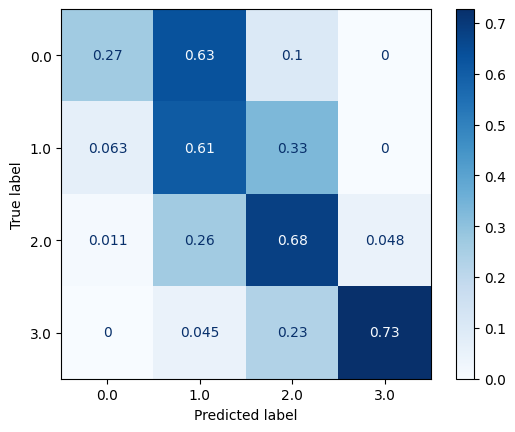

In [87]:
y_test_pred = best_new.predict(X_test)
print(classification_report(y_test, y_test_pred))

ConfusionMatrixDisplay.from_estimator(
    best_new, X_test, y_test,
    display_labels=["0.0", "1.0", "2.0", "3.0"],
    cmap="Blues",
    normalize="true"
)


With the new hyperparameter search, it does an awesome job on predicting "excellent" movies correctly.

#23 Summarize what you learned along the way and make recommendations to your boss on how this could be used moving forward, being careful not to over promise.

Over the course of this project, I created a decision-tree classifier to predict IMDB score for movies. Initially, the hyperparameter for the model was max_depth with the AUC score of 0.69. After changing my hyperparameter to min_samples_split, the AUC score increased to 0.79. The model performed well on predicting "excellent" movies correctly. ROC AUC score and the recall values are one of the most important metrics to evaluate the model. Although the model does a pretty good job on predicting excellent, good, and average movies, it does not perform well on predicting poor movies. I believe that this model would perform better if there are more movie data that belongs to the poor categories. As there are a variety of options for choosing a hyperparameter, it is also crucial to choose the right hyperparameter for the model to perform better. 